In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
from waymo_agent import *

In [3]:
# from kret_studies import *
# from kret_studies.notebook import *
# from kret_studies.complex import *

# logger = get_notebook_logger()

In [4]:
from waymo_agent.osmnx import *
from waymo_agent.osmnx.inspect import *
from waymo_agent.osmnx.osmnx_constants import *
from waymo_agent.osmnx.sparsify import *
from waymo_agent.osmnx.utils import _max_speed_int
from waymo_agent.osmnx.post_process_enrichment import *

#### Load Sparse Graph

In [5]:
config = EnvConfig()
config.map_name

'manhattan-sparse-774-nodes-enriched.graphml'

In [6]:
G_raw = ox.load_graphml(filepath=MAP_DIR / config.map_name)
post_load(G_raw)

In [7]:
inspect_graph(G_raw)

Graph has 774 nodes and 1613 edges.
Sample node -sample_node_id=42428714- attributes: {'y': 40.7947149, 'x': -73.9718975, 'highway': 'traffic_signals', 'street_count': 4, 'lambda': '0.018847330633433898', 'x_centered': '597.5654856147012', 'y_centered': '4440.724791307934', 'x_norm': '0.08344324979631478', 'y_norm': '0.6200969047879688'}

Sample edge attributes: {'osmid': 587061855, 'highway': 'secondary', 'maxspeed': 40.2335, 'name': 'West 72nd Street', 'oneway': False, 'reversed': True, 'length': 270.840318810079, 'geometry': <LINESTRING (-73.982 40.779, -73.982 40.779, -73.979 40.777, -73.979 40.777)>, 'unit': 'kph', 'travel_time_min': '0.40390269622589975'}


In [8]:
env = RideShareEnv()
G = env.graph

/Users/Akseldkw/micromamba/envs/kret_312/lib/python3.12/site-packages/gymnasium/spaces/box.py:236: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/Users/Akseldkw/micromamba/envs/kret_312/lib/python3.12/site-packages/gymnasium/spaces/box.py:306: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


In [9]:
obs, info = env.reset()

In [10]:
from waymo_agent.osmnx.shortest_path import calculate_longest_path


maxlen, path = calculate_longest_path(G, weight="length")
maxlen, len(path)

(18244.60388871296, 59)

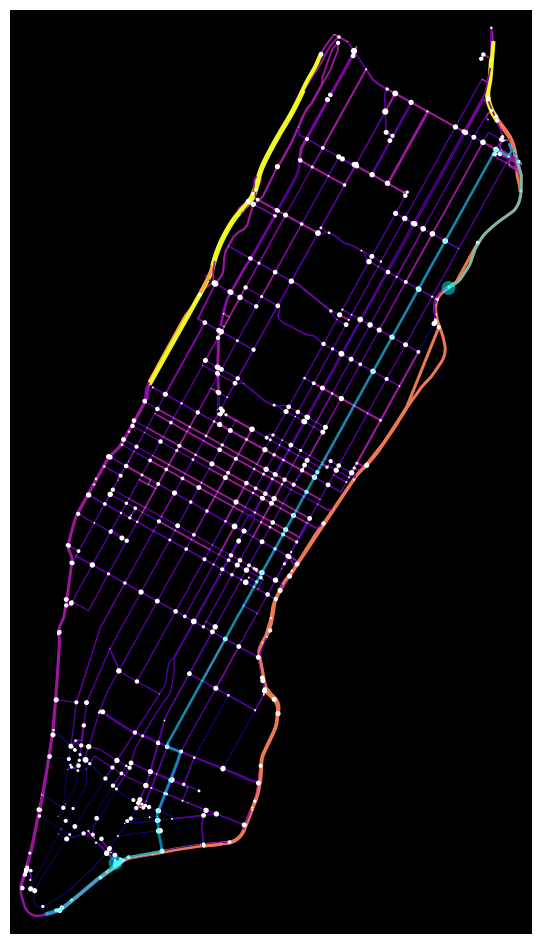

(<Figure size 1200x1200 with 1 Axes>, <Axes: >)

In [11]:
edge_colors, edge_widths = get_edge_color_by_speed(G)
node_colors, node_sizes = get_node_colors_and_sizes(G)
fig, ax = ox.plot_graph(
    G,
    edge_color=edge_colors,
    edge_linewidth=edge_widths,
    node_size=node_sizes,
    node_color=node_colors,
    figsize=(12, 12),
    show=False,
    bgcolor="black",
)
ox.plot_graph_route(G, path, route_color="cyan", route_linewidth=2.0, ax=ax, orig_dest_node_size=100)

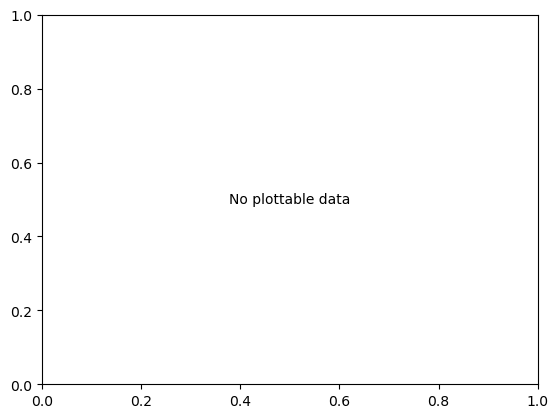

In [12]:
hist_edge_or_node_attr(G, "x_norm", "node")

In [20]:
node_attr = attrs_in_graph(G, "node")
edge_attr = attrs_in_graph(G, "edge")

In [21]:
node_attr

defaultdict(set,
            {'y': {'float'},
             'x': {'float'},
             'highway': {'str'},
             'street_count': {'int'},
             'lambda': {'str'},
             'x_centered': {'str'},
             'y_centered': {'str'},
             'x_norm': {'str'},
             'y_norm': {'str'},
             'ref': {'str'}})

In [22]:
edge_attr

defaultdict(set,
            {'osmid': {'int', 'list'},
             'highway': {'str'},
             'maxspeed': {'float'},
             'name': {'list', 'str'},
             'oneway': {'bool'},
             'reversed': {'bool', 'list'},
             'length': {'float'},
             'geometry': {'LineString'},
             'lanes': {'list', 'str'},
             'unit': {'str'},
             'travel_time_min': {'str'},
             'bridge': {'str'},
             'ref': {'list', 'str'},
             'tunnel': {'list', 'str'},
             'width': {'str'},
             'access': {'str'},
             'junction': {'str'}})